Using virtual environment venv kernel version Python 3.10.12

## Notes
- Using the updated isolate function - watch for updates to the master branch.

- Also need to use the updated normalize function - takes `jac_geom = True` and `jac_log = False` as arguments. Then, don't need to take exponential in step 4

- Should this entire thing just be a function...? (i.e. .py)

- In (4): should `tissue_data` be from nib instead? Right now, using .get_fdata(), which is stored in disk; or does this matter, since q-form = s-form?

- With (4): we are calculating tissue volume - so using the atlas on volume, rather than probability

In [ ]:
# use the updated module from isolate branch
#!pip install --force-reinstall git+https://github.com/DiedrichsenLab/SUITPy.git@master

# version of suit being used now: from isolation branch as of May 25, I think (on the day with history "hotfix" in the isolation branch)
# as of May 28, installed the newer version from this branch - just reinstalled it
# actually now as of May 28, 12:54 pm, using the master branch again...we shall see if that works. Since now that we've updated qform = sform, shouldn't run into the mismatch issue.

# June 1: clone uodated branch (developer branch)

In [ ]:
#!pip install git+https://github.com/DiedrichsenLab/SUITPy.git@develop
# As of June 1

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Cloning https://github.com/DiedrichsenLab/SUITPy.git (to revision develop) to /local/scratch/tmp/pip-req-build-y2krniqe
  Running command git clone --filter=blob:none --quiet https://github.com/DiedrichsenLab/SUITPy.git /local/scratch/tmp/pip-req-build-y2krniqe
  Running command git checkout -b develop --track origin/develop
  Switched to a new branch 'develop'
  Branch 'develop' set up to track remote branch 'develop' from 'origin'.
  Resolved https://github.com/DiedrichsenLab/SUITPy.git to commit 9b62cc3158d1853e377d8500a48878577e73ffac
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 23.2 MB/s  0:00:00 21.8 MB/s eta 0:00:01
   ━━━━━━━━━

In [9]:
# Import packages
from nilearn import plotting as npl
import nibabel as nib
import ants
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import SUITPy as suit
import SUITPy.atlas as atlas

#import tissue_extractor as te

from pathlib import Path

In [ ]:
#!pip list

#suit.isolate?
# check downloaded the correct branch

# loop for all subjects

In [ ]:
# tissues: 'gm', 'wm', 'csf', 
# "tissue" is a bad name...think of something more accurate to incl csf, etc.
tissue = 'wm' # default
tissue_dict = {
    'gm': 'c1',
    'wm': 'c2',
    'csf': 'c3'
}

# directories
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'
p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')


for i in range(0, p_df.shape[0]):
    p_id = p_df['ID'].iloc[i]
    week = (p_df['Week'].iloc[i]).strip() # sometimes have extra white spaces
    p_centre = (str(p_df['Centre'].iloc[i])).strip()
    refT1 = (p_df['RefT1'].iloc[i]).strip()

    subj_id = f'{p_centre.strip()}_{p_id}'

    t1_path = f'{anat_dir}/{subj_id}/{week}/{subj_id}_{week}_T1.nii'
    tissue_path = f'{anat_dir}/{subj_id}/{week}/{tissue_dict[tissue]}{subj_id}_{week}_T1.nii'

    # check that paths exist
    if not Path(t1_path).is_file():
        print(f'T1 path does not exist for {subj_id} in week {week}')
        continue
    if not Path(tissue_path).is_file():
        print(f'{tissue} path does not exist for {subj_id} in week {week}')
        continue

    # make a new folder inside subject's week folder for results
    results_path = Path(anat_dir)/subj_id/week/f'{tissue}_results'
    results_path.mkdir(parents=True, exist_ok = True) # exist_ok = True


    # 1. SUITPy isolation
    """
    Isolate cerebellum from anatomical
    Input: t1-weighted anatomical
    Output: cerebellar isolation mask
    """
    mask = suit.isolate(t1_path, result_folder = results_path, verbose = 1)
    mask_path = Path(results_path)/f'{subj_id}_{week}_T1_cerebellum_dseg.nii.gz' # path to the mask


    # 2. SUITPy normalization
    """
    Normalize T1w anatomical in native space to SUIT (or other) space
    Inputs:
        T1w anatomical
        cerebellar isolation mask (from `suit.isolate`)
    Outputs:
        Returns a dictionary with several files, including optional outputs:
            (log) Jacobian determinant: change in voxel sizes
            fwd_transforms: transformation file for native to SUIT space
    """
    norm_results = suit.normalize(
        source_file = t1_path,
        mask_file = str(mask_path),
        space = 'SUIT', # make sure to use same space everywhere

        # optional files to write
        write_jacobian_determinant = True,
        write_ants_transform = True, # if working in ANTs; probably not needed for us.
        write_normalized = True,
        write_inv_deformation = True,

        result_folder = results_path,
        # jac_log = False,
        # jac_geom = True,
        verbose = 1
    )


    # 3. SUITPy reslice image
    """
    Reslice image from a given space to another (e.g. forward: native to SUIT space)
    Inputs:
        tissue segmentation file 
            - (e.g. c1 file)
            - tissue volume (e.g. grey matter volume)
        deformation image: from normalization module (transformation file)
            If native --> template, use forward deformation

        cerebellar isolation mask (optional)
            - use if interested in cerebellum
    Output:
        - resliced image: tissue in SUIT space
        - probability of tissue in space
    """
    resliced_img = suit.reslice_image(source_image = tissue_path,
                                      deformation = norm_results['fwd_deformation'],
                                      mask = str(mask_path)
                                      )
    nib.save(resliced_img, Path(results_path)/f'{subj_id}_{week}_T1_tissue_resliced.nii')

    # optional check
    """
    print("resliced (prob) image")
    npl.plot_anat(resliced_img)
    print("\n")
    """

    # 4. calculate (modulated) tissue volume in SUIT space
    voxel_dim = resliced_img.header.get_zooms()[:3]
    voxel_vol = np.prod(voxel_dim)

    tissue_data = resliced_img.get_fdata() # voxel orientation - stored in disk
    jac_det_img = nib.load(norm_results['jacobian_determinant'])
    jac_det = jac_det_img.get_fdata()

    # IF NOT USING UPDATED NORMALIZE FUNCTION
    jac_det = np.exp(jac_det)

    tissue_vol = tissue_data*jac_det*voxel_vol

    # save the tissue volume file: first save Numpy array back to Nifti, then save file
    tissue_vol_img = nib.Nifti1Image(tissue_vol, resliced_img.affine, resliced_img.header)
    nib.save(tissue_vol_img, Path(results_path)/f'{subj_id}_{week}_T1_{tissue}_vol.nii')

    # optional check
    """
    print("volume image")
    npl.plot_anat(tissue_vol_img)
    print("\n")
    """

    # 5. Put in atlas
    """
    In cerebellar atlas; see SUITPy documentation for atlas and map options
    """

    # this part is unnecessary, already doing this in make_summarized_tsv; just a little check ig
    
    atlas.fetch_atlas('Nettekoven_2024')
    df = atlas.summarize_data(tissue_vol_img,
                              space = 'SUIT',
                              stats = ['nanmean'],
                              atlas = 'Nettekoven_2024',
                              maps = 'atl-NettekovenAsym32'
                              )
    df[f'{tissue}v'] = df['nanmean'] * (df['size']/voxel_vol)

    df.rename(columns={'nanmean': f'avg_{tissue}v'}, inplace = True)
    print(f'{subj_id} {week} done')

# test on single subject, single week

In [18]:
t1_path = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/CU_2310/W0/CU_2310_W0_T1.nii'
tissue_path = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/CU_2310/W0/c2CU_2310_W0_T1.nii'
results_path = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/CU_2310/W0/wm_results'
subj_id = 'CU_2310'
week = 'W0'
tissue = 'wm'

mask_path = Path(results_path)/f'{subj_id}_{week}_T1_cerebellum_dseg.nii.gz' # path to the mask

In [ ]:
in_suit = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/CU_2310/W0/wm_results/CU_2310_W0_T1_wm_vol.nii'

In [ ]:
inv_trans = suit.reslice_image(in_suit, # reslice wm volume file from suit space into native (aligned anat) space
                         deformation# Linear## = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/CU_2310/W0/wm_results/CU_2310_W0_T1_from-SUIT_mode-image_xfm.nii.gz',
                         )

In [43]:
nib.save(inv_trans, f'{subj_id}_{tissue}_inv_trans.nii')

## Think about this
Should I reslice the volume image or the probability image back into individual space?

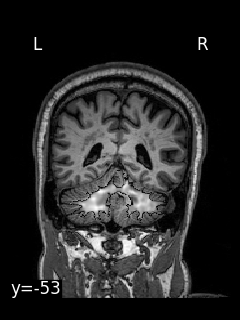

In [41]:
npl.plot_img(in_suit, display_mode='y',threshold=0.1, cut_coords=[-53.0], 
             bg_img = t1_path, # why am I plotting the suit space image against anatomical in native space
             colorbar=False,
             #cmap='tab20',
             black_bg = True
             )

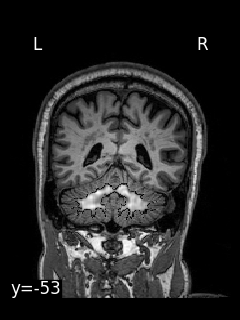

In [42]:
npl.plot_img(inv_trans, display_mode='y',threshold=0.1, cut_coords=[-53.0], 
             bg_img = t1_path,
             colorbar=False,
             #cmap='tab20',
             black_bg = True
             )

In [ ]:
"""

t1_path = 'smarts_cerebellum/anatomicals/CU_2310/W0/CU_2310_W0_T1.nii'
tissue_path = 'smarts_cerebellum/anatomicals/CU_2310/W0/c2CU_2310_W0_T1.nii'
results_path = 'smarts_cerebellum/anatomicals/CU_2310/W0/wm_results'
subj_id = 'CU_2310'
week = 'W0'
tissue = 'wm'


mask = suit.isolate(t1_path, result_folder = results_path, verbose = 1)
mask_path = Path(results_path)/f'{subj_id}_{week}_T1_cerebellum_dseg.nii.gz' # path to the mask





norm_results = suit.normalize(
        source_file = t1_path,
        mask_file = str(mask_path),
        space = 'SUIT', # make sure to use same space everywhere

        # optional files to write
        write_jacobian_determinant = True,
        write_ants_transform = True,
        write_normalized = True,
        write_inv_deformation = True,

        result_folder = results_path,
        # jac_log = False,
        # jac_geom = True,
        verbose = 1
    )



resliced_img = suit.reslice_image(source_image = tissue_path,
                                      deformation = norm_results['fwd_deformation'],
                                      mask = str(mask_path)
                                      )
nib.save(resliced_img, Path(results_path)/f'{subj_id}_{week}_T1_tissue_resliced')



voxel_dim = resliced_img.header.get_zooms()[:3]
voxel_vol = np.prod(voxel_dim)

tissue_data = resliced_img.get_fdata() # voxel orientation - stored in disk
jac_det_img = nib.load(norm_results['jacobian_determinant'])
jac_det = jac_det_img.get_fdata()

# IF NOT USING UPDATED NORMALIZE FUNCTION
jac_det = np.exp(jac_det)

tissue_vol = tissue_data*jac_det*voxel_vol

# save the tissue volume file: first save Numpy array back to Nifti, then save file
tissue_vol_img = nib.Nifti1Image(tissue_vol, resliced_img.affine, resliced_img.header)
nib.save(tissue_vol_img, Path(results_path)/f'{subj_id}_{week}_T1_{tissue}_vol.nii')





atlas.fetch_atlas('Nettekoven_2024')
df = atlas.summarize_data(tissue_vol_img,
                            space = 'SUIT',
                            stats = ['nanmean'],
                            atlas = 'Nettekoven_2024',
                            maps = 'atl-NettekovenAsym32'
                            )
df[f'{tissue}v'] = df['nanmean'] * (df['size']/voxel_vol)

df.rename(columns={'nanmean': f'avg_{tissue}v'}, inplace = True)
df['image_name'] = tissue_vol_img
display(df.head())
print(f'{subj_id} {week} done')

"""